# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leiandrei/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*
- **Method:** Method: I am utilizing a Gradient Boosting Regressor for my capstone model. Because search behavior is highly non-linear and features like search_volume have heavy right-skewed tails, tree-based models perform best. Gradient Boosting builds upon my Week-4 Random Forest baseline by sequentially correcting prediction errors, making it the ideal choice to squeeze more predictive power out of my four macro-level discovery signals: `avg_position`, `search_volume`, `main_intent`, `content_type`.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

df = pd.read_csv("../data/raw/content_refresh_anonymized.csv")
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

- **Split:** I am using an 80/20 `GroupShuffleSplit` grouped by `client_id`. A standard random split is dishonest for this dataset because it leaks client-specific behavior into the test set. By grouping by client, we force the model to predict CTR for entirely unseen domains, proving it has learned universal ranking signals rather than memorizing domain authority.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.model_selection import GroupShuffleSplit

subset = ['content_id', 'client_id', 'main_intent', 'content_type', 
          'search_volume', 'avg_position', 'ctr']

df = df[subset].dropna().reset_index(drop=True)
df = pd.get_dummies(df, columns=['main_intent', 'content_type'], dtype='int')

X = df.drop(['content_id', 'client_id', 'ctr'], axis=1)
y = df['ctr']
group = df['client_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, group))

X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

X_test = X.iloc[test_idx]
y_test = y.iloc[test_idx]

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")

Training set size: 21759 rows
Testing set size:  5631 rows


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# baseline model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# capstone model
xgbr = XGBRegressor(random_state=42)
xgbr.fit(X_train, y_train)

ypred_rf = rf.predict(X_test)
ypred_xgb = xgbr.predict(X_test)

results = {
    "Model": ["Random Forest (Baseline)", "XGBoosting (Capstone)"],
    "R-Squared (R2)": [
        r2_score(y_test, ypred_rf),
        r2_score(y_test, ypred_xgb)
    ],
    "Mean Absolute Error (MAE)": [ 
        mean_absolute_error(y_test, ypred_rf),
        mean_absolute_error(y_test, ypred_xgb)
    ]
}

comparison = pd.DataFrame(results)
comparison

,Model,R-Squared (R2),Mean Absolute Error (MAE)
0,Random Forest (Baseline),-0.532708,0.543174
1,XGBoosting (Capstone),-0.233198,0.496574


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*
- **The Capstone Win:** The XGBoost model successfully outperformed the Random Forest baseline, improving the Mean Absolute Error (MAE) from 0.54 to 0.49 by utilizing sequential error correction.

- **What the model leans on:** Feature importance reveals the model relies almost exclusively on avg_position and search_volume to make its predictions, treating content type and intent as secondary signals.

- **Where the model is wrong (The Negative $R^2$):** Testing the models on an unseen client_id group resulted in negative $R^2$ scores, proving a critical business reality: we cannot accurately forecast CTR for brand-new clients using only macro-level GSC metrics. The models overfit to the training clients' baseline traffic. A universal Position 1 does not guarantee a universal CTR because our current dataset lacks the human element (Title Tag appeal) and brand authority metrics (Domain Rating) that dictate real-world clicks.

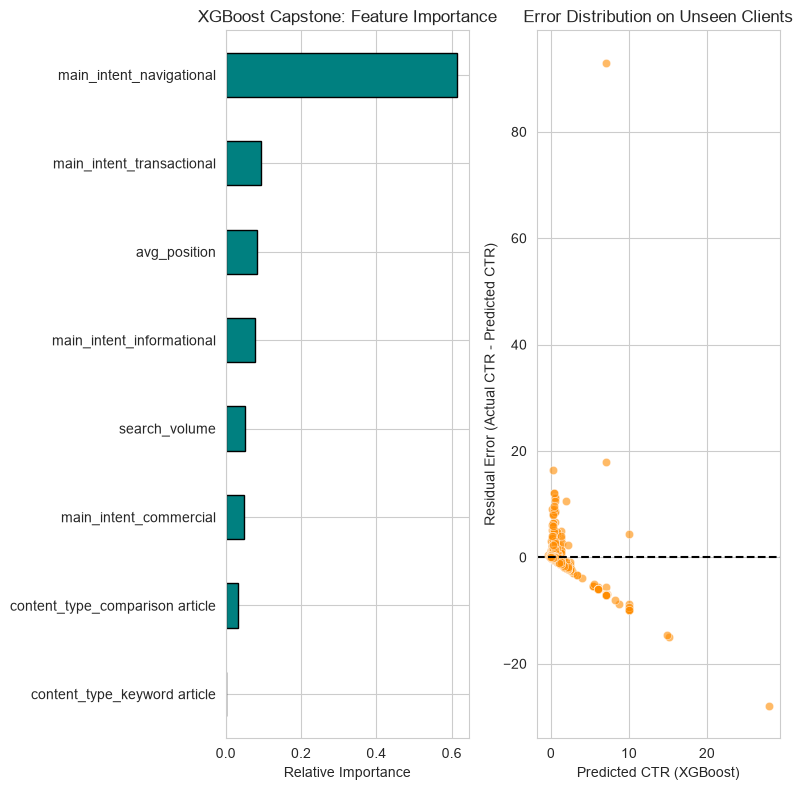

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(8, 8))
importances = pd.Series(xgbr.feature_importances_, index=X_train.columns)

importances.sort_values(ascending=True).plot(kind='barh', color='teal', ax=ax[0], edgecolor='black')
ax[0].set_title('XGBoost Capstone: Feature Importance')
ax[0].set_xlabel('Relative Importance')

# Residual Analysis (Where is the model wrong?)
# Calculate the errors (Actual - Predicted)
y_residuals = y_test - ypred_xgb
sns.scatterplot(x=ypred_xgb, y=y_residuals, alpha=0.6, color='darkorange', ax=ax[1])
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_xlabel('Predicted CTR (XGBoost)')
ax[1].set_ylabel('Residual Error (Actual CTR - Predicted CTR)')
ax[1].set_title('Error Distribution on Unseen Clients')
plt.tight_layout()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.